# Fine-tunung LoRA of Stable diffusion using HuggingFace Diffusers

----

- Conda env : [cv_playgrounds](../README.md#setup-a-conda-environment)

-----

## Reference :

- ***Github***:
    - https://github.com/metamath1/pytorch-stable-diffusion-fine-tuning

## Step 1

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torchvision import transforms
import transformers, datasets, diffusers
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from diffusers.optimization import get_scheduler
from diffusers import StableDiffusionPipeline

from tqdm import tqdm
from PIL import Image

from peft import LoraConfig
from peft.utils import get_peft_model_state_dict


print(f"transformers version : {transformers.__version__}")
print(f"datasets version     : {datasets.__version__}")
print(f"diffusers version    : {diffusers.__version__}")

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

W1005 15:23:15.360000 23611 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


transformers version : 4.56.2
datasets version     : 4.1.1
diffusers version    : 0.35.1


## Step 2 : Download SD model from Huggingface


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

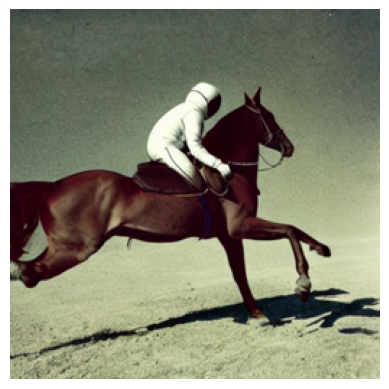

In [2]:
PRE_TRAINED_MODEL_NAME="sd-legacy/stable-diffusion-v1-5"

origin_pipe = StableDiffusionPipeline.from_pretrained(PRE_TRAINED_MODEL_NAME)
origin_pipe = origin_pipe.to(device)
prompt = " a photograph of an astronaut riding a horse"
origin_image = origin_pipe(prompt).images[0].resize((256, 256))

plt.imshow(origin_image)
plt.axis('off')
plt.show()

In [3]:
noise_scheduler = DDPMScheduler.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="scheduler"
)

tokenizer = CLIPTokenizer.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="tokenizer"
)

# Frozen
text_encoder = CLIPTextModel.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="text_encoder"
)

# Frozen
vae = AutoencoderKL.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="vae"
)

# Will be fine-tuned
unet = UNet2DConditionModel.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="unet"
)


## Step 3. Download training data for fine-tuning

140-th Image Size: (1280, 1280)
140-th Caption   : a very cute looking cartoon character with big eyes


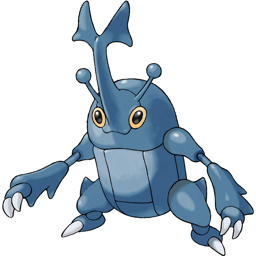

In [4]:
dataset = datasets.load_dataset("xiaoqia/poken")
idx = 140
print(f"{idx}-th Image Size: {dataset['train'][idx]['image'].size}")
print(f"{idx}-th Caption   : {dataset['train'][idx]['text']}")
dataset['train'][idx]['image'].resize((256, 256))

## Step 4. Data Loader

### Step 4.1 Preprocessing for Text

In [5]:
# Check the max_length of tokenizer
print(f"the max_length of tokenizer : {tokenizer.model_max_length}")

# Test tokenizer
token = tokenizer(dataset['train'][idx]['text'],
                  max_length=tokenizer.model_max_length,
                  padding='max_length',
                  truncation=True,
                  return_tensors='pt')
print(f" -- Text  : {dataset['train'][idx]['text']}")
print(f" >> Token : {token}")

# Preprocessing for caption tokenize
def tokenize_captions(examples, caption_column='text', is_train=True):
    captions = []

    for caption in examples[caption_column]:
        # one caption
        if isinstance(caption, str):
            captions.append(caption)
        # multiple caption
        elif isinstance(caption, (list, np.ndarray)):
            # take a random caption if there are multiple
            captions.append(random.choice(caption) if is_train else caption[0])
        else:
            raise ValueError(
                f"Caption column `{caption_column}` should contain either strings or lists of strings."
            )

    inputs = tokenizer(
        captions, max_length=tokenizer.model_max_length, padding="max_length", truncation=True, return_tensors="pt"
    )

    return inputs.input_ids

the max_length of tokenizer : 77
 -- Text  : a very cute looking cartoon character with big eyes
 >> Token : {'input_ids': tensor([[49406,   320,  1070,  2242,  1312,  7651,  4009,   593,  1205,  3095,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
  

### Step 4.2 Preprocessing for Image


In [6]:
IMG_SIZE = 512
CENTER_CROP = True
RANDOM_FLIP = True

# Preprocessing the datasets.
train_transforms = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(IMG_SIZE) if CENTER_CROP else transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip() if RANDOM_FLIP else transforms.Lambda(lambda x: x),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]), # (0,1)->(-1,1)
    ]
)

### Step 4. 3 Apply the preprocess function to dataset

In [7]:
def preprocess_train(examples, image_column='image'):
    images = [image.convert("RGB") for image in examples[image_column]]

    # preprocessing for image
    examples["pixel_values"] = [train_transforms(image) for image in images]

    # preprocessing for text
    examples["input_ids"] = tokenize_captions(examples)

    return examples



# apply preprocess_train at train dataset
train_dataset = dataset["train"].with_transform(preprocess_train)

# check dataset
print(f"Data fields : {train_dataset.column_names}")
print(f"Data keys   : {train_dataset[0].keys()}")





Data fields : ['image', 'text']
Data keys   : dict_keys(['image', 'text', 'pixel_values', 'input_ids'])


### Step 4.4 DataLoader

In [8]:
def collate_fn(examples):
    # (C, H, W), ..., (C, H, W) -> stack -> (N, C, H, W)
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    # tensor.contiguous()
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()

    # {(77,), ..., (77,)}_N -> stack -> (N, 77)
    input_ids = torch.stack([example["input_ids"] for example in examples])

    return {"pixel_values": pixel_values, "input_ids": input_ids}


# 데이터로더 생성

BATCH_SIZE = 2 # 2 for rtx 3090
NUM_WORKERS = 1 # 4 for rtx 3090

# DataLoaders creation:
train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=BATCH_SIZE,
    # num_workers=NUM_WORKERS,
)

# Test Dataloader
train_dataloader_iter = iter(train_dataloader)
mini_batch = next(train_dataloader_iter)

# # 이미지 데이터,                  캡션 데이터
print(f"Image shape     : {mini_batch['pixel_values'].shape}")
print(f"Text data shape : {mini_batch['input_ids'].shape}")


print(f"The number of iteration : {len(train_dataloader)}")

# # 참고 text_encoder의 출력
# # BaseModelOutputWithPooling 이 되돌려지는데 [0]이 last_hidden_state
# # 트랜스포머 인코더의 마지막 히든층 츨력이므로 크기는 (batch size, time step, model dim)
print(f"The shape of text encoder : {text_encoder(mini_batch['input_ids'])[0].shape}")


Image shape     : torch.Size([2, 3, 512, 512])
Text data shape : torch.Size([2, 77])
The number of iteration : 417
The shape of text encoder : torch.Size([2, 77, 768])


## Step 5. Training

### Setup 5.1. Update the status of models for fine-tuning

In [9]:
# For FP16 : weight_dtype = torch.float32
# weight_dtype = torch.float16 # half precision

# Freeze unet, vae and text encoder
unet.requires_grad_(False)
vae.requires_grad_(False)
text_encoder.requires_grad_(False)


LORA_RANK = 4

# Freeze the unet parameters before adding adapters
for param in unet.parameters():
    param.requires_grad_(False)

unet_lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)

# Move text_encode and vae to gpu/mps
text_encoder.to(device)
vae.to(device)
unet.to(device)

# Add adapter and make sure the trainable params are in float32.
unet.add_adapter(unet_lora_config)

###### Check this part
# if weight_dtype == torch.float16:
#     # only upcast trainable parameters (LoRA) into fp32
#     cast_training_params(unet, dtype=torch.float32)

lora_layers = filter(lambda p: p.requires_grad, unet.parameters())


### 5.2. Setup Optimizer and Scheduler

In [10]:
EPOCHS = 30
LEARNING_RATE = 1e-05

# Setup Optimizer
optimizer = torch.optim.AdamW(
        unet.parameters(),
        lr=LEARNING_RATE,
    )
# Setup Scheduler
lr_scheduler = get_scheduler(
        'linear',
        optimizer=optimizer,
        num_warmup_steps=500,
        num_training_steps=EPOCHS * len(train_dataloader)
    )

## Step 10


In [11]:
from pathlib import Path
Path("temp/sd_lora_model").mkdir(parents=True, exist_ok=True)

use_amp = False
prediction_type = None # 'epsilon'  or 'v_prediction'

train_losses = []

for epoch in range(EPOCHS):
    for step, batch in enumerate(tqdm(train_dataloader)):
        # pytorhc amp autocast
        # with torch.autocast(device_type=device, dtype=weight_dtype, enabled=use_amp):
        # Convert images to latent space
        latents = vae.encode(
            batch["pixel_values"].to(device)
        ).latent_dist.sample()
        latents = latents * vae.config.scaling_factor

        # --------
        # Sample noise that we'll add to the latents
        noise = torch.randn_like(latents)

        bsz = latents.shape[0]
        # Sample a random timestep for each image
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=latents.device)
        timesteps = timesteps.long()

        # Add noise to the latents according to the noise magnitude at each timestep
        # (this is the forward diffusion process)
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # Get the text embedding for conditioning, [0]: last_hidden_state
        encoder_hidden_states = text_encoder(batch["input_ids"].to(device) )[0]

        # Set targets in the noise scheduler based on whether the prediction type is noise or image.
        if prediction_type is not None:
            # set prediction_type of scheduler if defined
            noise_scheduler.register_to_config(prediction_type=prediction_type)

        if noise_scheduler.config.prediction_type == "epsilon":
            target = noise
        elif noise_scheduler.config.prediction_type == "v_prediction":
            target = noise_scheduler.get_velocity(latents, noise, timesteps)
        else:
            raise ValueError(f"Unknown prediction type {noise_scheduler.config.prediction_type}")

        # Predict the noise residual and compute loss
        model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

        loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")


        with torch.no_grad():
            train_losses.append(loss.item())

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()
        # lr_scheduler.step()
        # optimizer.zero_grad()

    # print loss
    avg_loss = sum(train_losses[-100:])/100
    print(f'Finished epoch {epoch+1}. Average of the last 100 loss values: {avg_loss:05f}')
    unet.save_pretrained("temp/sd_lora_model")

100%|██████████| 417/417 [10:05<00:00,  1.45s/it]


Finished epoch 1. Average of the last 100 loss values: 0.050405


100%|██████████| 417/417 [10:41<00:00,  1.54s/it]


Finished epoch 2. Average of the last 100 loss values: 0.050211


100%|██████████| 417/417 [10:54<00:00,  1.57s/it]


...

Finished epoch 28. Average of the last 100 loss values: 0.047757


100%|██████████| 417/417 [09:19<00:00,  1.34s/it]


Finished epoch 29. Average of the last 100 loss values: 0.053498


100%|██████████| 417/417 [09:14<00:00,  1.33s/it]


Finished epoch 30. Average of the last 100 loss values: 0.053974


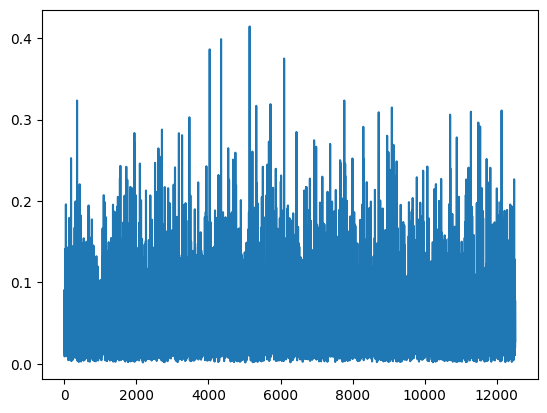

In [12]:
plt.plot(train_losses)
plt.show()

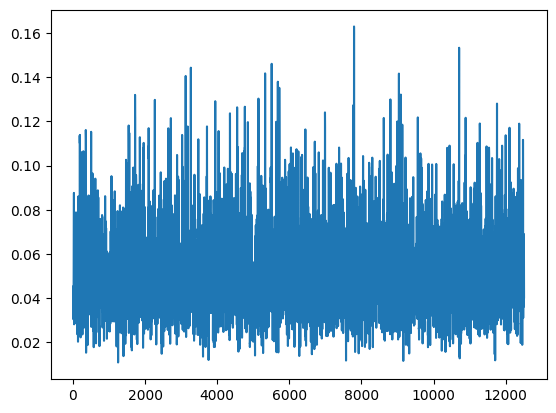

In [13]:
import pandas as pd
losses_sr = pd.Series(train_losses)
loss_mv = losses_sr.rolling(window=5).mean()

plt.plot(loss_mv)

In [14]:
prompt = ["a very cute looking cartoon character with big eyes"]

height = 512  # default height of Stable Diffusion
width = 512  # default width of Stable Diffusion

num_inference_steps = 20  # Number of denoising steps
guidance_scale = 7.5  # Scale for classifier-free guidance

generator = torch.manual_seed(2)  # Seed generator to create the initial latent noise

batch_size = len(prompt)

text_input = tokenizer(
    prompt, max_length=tokenizer.model_max_length,
    padding="max_length", truncation=True, return_tensors="pt"
)
print(len(text_input['input_ids'][0]))
text_input

77


{'input_ids': tensor([[49406,   320,  1070,  2242,  1312,  7651,  4009,   593,  1205,  3095,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0]])}

In [15]:
with torch.no_grad():
    text_embeddings = text_encoder(text_input['input_ids'].to(device))[0]

text_embeddings.shape

torch.Size([1, 77, 768])

In [16]:
max_length = text_input['input_ids'].shape[-1]

uncond_input = tokenizer([""] * batch_size, padding="max_length", max_length=max_length, return_tensors="pt")

uncond_embeddings = text_encoder(uncond_input['input_ids'].to(device))[0]

In [17]:
# (1, 77, 768), (1, 77, 768) => (2, 77, 768)
text_embeddings = torch.cat([uncond_embeddings, text_embeddings])
text_embeddings.shape

torch.Size([2, 77, 768])

In [18]:
latents = torch.randn(
    (batch_size, unet.config.in_channels, height // 8, width // 8),
    generator=generator,
).to(device)

In [19]:
noise_scheduler.set_timesteps(num_inference_steps)
noise_scheduler.timesteps

tensor([951, 901, 851, 801, 751, 701, 651, 601, 551, 501, 451, 401, 351, 301,
        251, 201, 151, 101,  51,   1])

In [20]:
lora_scale = 0.9

for t in tqdm(noise_scheduler.timesteps):
    # expand the latents if we are doing classifier-free guidance to avoid doing two forward passes.
    latent_model_input = torch.cat([latents] * 2)

    # predict the noise residual
    with torch.no_grad():
        noise_pred = unet(
            latent_model_input,
            t,
            encoder_hidden_states=text_embeddings,
            cross_attention_kwargs={"scale": lora_scale},
        ).sample

    # perform guidance
    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
    # CFG eq(6)
    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

    # compute the previous noisy sample x_t -> x_t-1
    latents = noise_scheduler.step(noise_pred, t, latents).prev_sample

100%|██████████| 20/20 [00:06<00:00,  2.95it/s]


In [21]:

latents = 1 / 0.18215 * latents
with torch.no_grad():
    image = vae.decode(latents).sample

In [22]:
image.shape

torch.Size([1, 3, 512, 512])

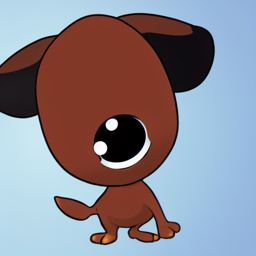

In [23]:
image = (image / 2 + 0.5).clamp(0, 1).squeeze()
image = (image.permute(1, 2, 0) * 255).to(torch.uint8).cpu().numpy()
image = Image.fromarray(image)
image.resize((256, 256))

In [24]:
from diffusers import StableDiffusionPipeline

In [25]:
pipeline = StableDiffusionPipeline.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    text_encoder=text_encoder,
    vae=vae,
    unet=unet,
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [26]:
pipeline.to(device);

  0%|          | 0/20 [00:00<?, ?it/s]

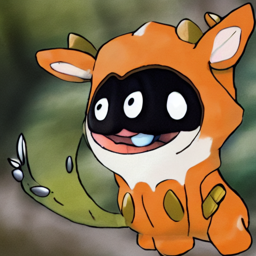

In [27]:
lora_scale = 0.9
pipeline_output = pipeline(
    prompt=["a very cute looking cartoon character with big eyes"],
    num_inference_steps=20,
    cross_attention_kwargs={"scale": lora_scale},
    generator=torch.manual_seed(101)
)
pipeline_output.images[0].resize((256, 256))

  0%|          | 0/20 [00:00<?, ?it/s]

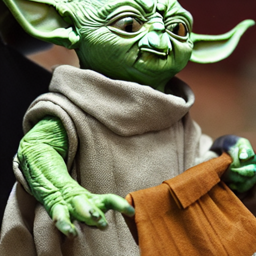

In [28]:
lora_scale = 0.9

pipeline_output = pipeline(
    prompt=["Yoda"],
    num_inference_steps=20,
    cross_attention_kwargs={"scale": lora_scale},
    generator=torch.manual_seed(101)
)
pipeline_output.images[0].resize((256, 256))

  0%|          | 0/20 [00:00<?, ?it/s]

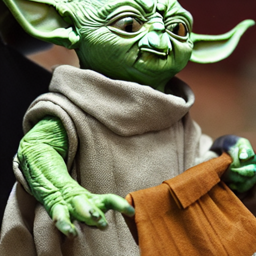

In [29]:
lora_scale = 0.9

pipeline_output = pipeline(
    prompt=["Yoda"],
    num_inference_steps=20,
    cross_attention_kwargs={"scale": lora_scale},
    generator=torch.manual_seed(101)
)
pipeline_output.images[0].resize((256, 256))


In [30]:
pipeline.save_pretrained("./temp/sd_lora_finetuning_save")

  0%|          | 0/20 [00:00<?, ?it/s]

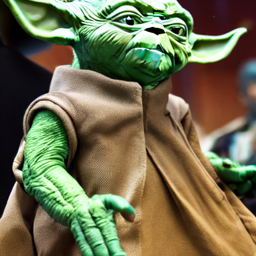

In [31]:
lora_scale = 0.5

pipeline_output = pipeline(
    prompt=["Yoda"],
    num_inference_steps=20,
    cross_attention_kwargs={"scale": lora_scale},
    generator=torch.manual_seed(101)
)
pipeline_output.images[0].resize((256, 256))

  0%|          | 0/20 [00:00<?, ?it/s]

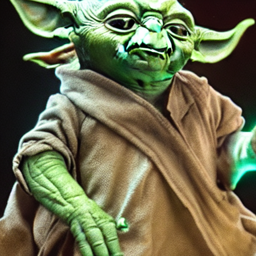

In [32]:
lora_scale = 0.1

pipeline_output = pipeline(
    prompt=["Yoda"],
    num_inference_steps=20,
    cross_attention_kwargs={"scale": lora_scale},
    generator=torch.manual_seed(101)
)
pipeline_output.images[0].resize((256, 256))

  0%|          | 0/20 [00:00<?, ?it/s]

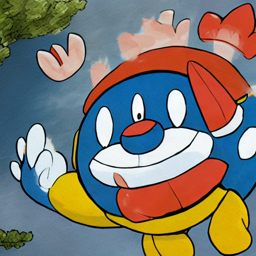

In [33]:
lora_scale = 0.9

pipeline_output = pipeline(
    prompt=["Doraemon"],
    num_inference_steps=20,
    cross_attention_kwargs={"scale": lora_scale},
    generator=torch.manual_seed(101)
)
pipeline_output.images[0].resize((256, 256))

  0%|          | 0/20 [00:00<?, ?it/s]

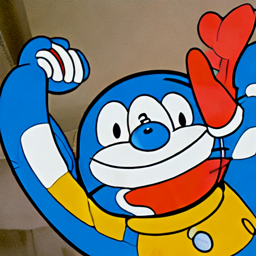

In [34]:
lora_scale = 0.1

pipeline_output = pipeline(
    prompt=["Doraemon"],
    num_inference_steps=20,
    cross_attention_kwargs={"scale": lora_scale},
    generator=torch.manual_seed(101)
)
pipeline_output.images[0].resize((256, 256))

  0%|          | 0/20 [00:00<?, ?it/s]

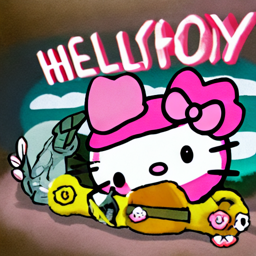

In [35]:
lora_scale = 0.9

pipeline_output = pipeline(
    prompt=["HelloKitty"],
    num_inference_steps=20,
    cross_attention_kwargs={"scale": lora_scale},
    generator=torch.manual_seed(101)
)
pipeline_output.images[0].resize((256, 256))

  0%|          | 0/20 [00:00<?, ?it/s]

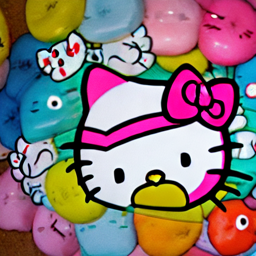

In [36]:
lora_scale = 0.01

pipeline_output = pipeline(
    prompt=["HelloKitty"],
    num_inference_steps=20,
    cross_attention_kwargs={"scale": lora_scale},
    generator=torch.manual_seed(101)
)
pipeline_output.images[0].resize((256, 256))

  0%|          | 0/20 [00:00<?, ?it/s]

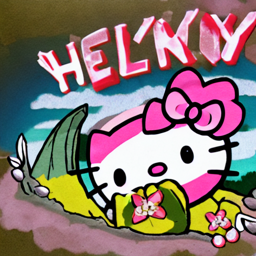

In [37]:
lora_scale = 1.0

pipeline_output = pipeline(
    prompt=["HelloKitty"],
    num_inference_steps=20,
    cross_attention_kwargs={"scale": lora_scale},
    generator=torch.manual_seed(101)
)
pipeline_output.images[0].resize((256, 256))